# CS303 Machine Learning Lab
## Experiment 1: Build and Test Your First Machine Learning Classifier using K-Nearest Neighbors (KNN)
### (24/CS/232)

**Aim:**
To build and evaluate a K-Nearest Neighbors (KNN) classifier using the Iris dataset, analyze the effect of different values of $k$, and understand how distance-based classification works in vector space.

**Objective:**
1. Load and explore the Iris dataset.
2. Understand the dataset structure, feature names, and class distribution.
3. Visualize relationships between features using Seaborn Pairplots.
4. Train a K-Nearest Neighbors classifier.
5. Compare classifier performance for different values of $k$.
6. Understand Euclidean distance and feature vector representation.
7. Interpret class probabilities using `predict_proba()`.
8. Document results for reproducibility.

**1. Importing Libraries & Loading the Dataset**

In [1]:
# importing required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from matplotlib.colors import ListedColormap
import warnings
warnings.filterwarnings('ignore')

# loading the dataset
iris = load_iris()
X = iris.data
y = iris.target

# converting to a dataframe for easier visualization
df = pd.DataFrame(X, columns=iris.feature_names)
df["Species"] = y

**2. Displaying Dataset Information**

In [2]:
# displaying the dimensions of the dataset
print("--- Dataset Shape ---")
print(df.shape)

# displaying the names of the independent variables
print("\n--- Feature Names ---")
print(iris.feature_names)

# displaying the names of the dependent target classes
print("\n--- Target Classes ---")
print(iris.target_names)

--- Dataset Shape ---
(150, 5)

--- Feature Names ---
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

--- Target Classes ---
['setosa' 'versicolor' 'virginica']


**3. Data Visualization**

Visualizing the class distribution and feature separability across the vector space.

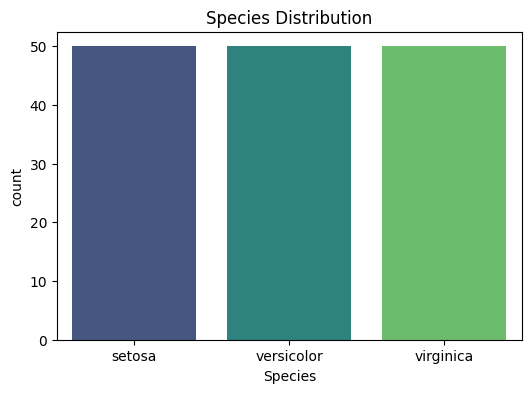

In [3]:
# plotting the species distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='Species', data=df, palette='viridis')
plt.title("Species Distribution")
plt.xticks(ticks=[0, 1, 2], labels=iris.target_names)
plt.show()

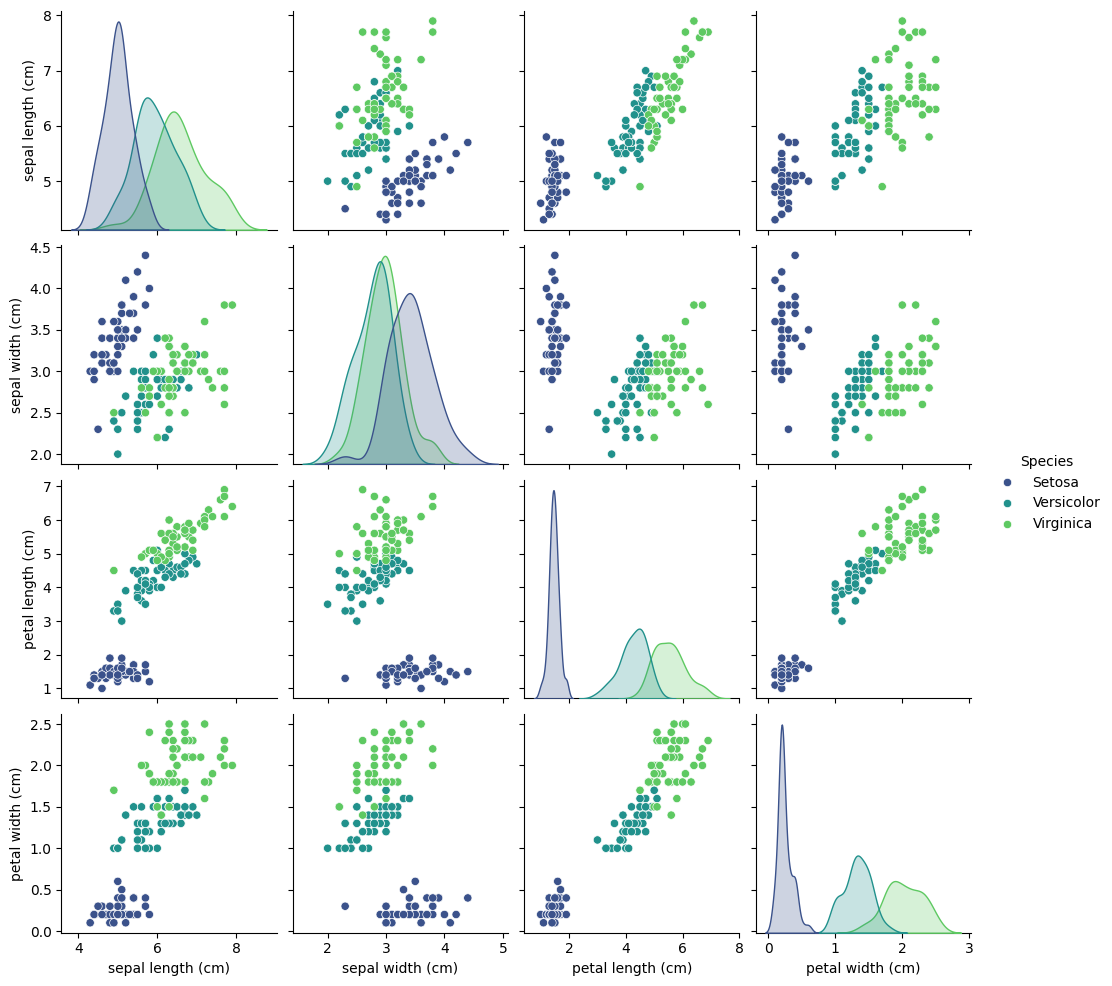

In [4]:
# mapping numeric targets back to string names for the pairplot legend
df["Species"] = df["Species"].replace({
    0: "Setosa",
    1: "Versicolor",
    2: "Virginica"
})

# plotting pairwise relationships between all features
sns.pairplot(df, hue="Species", palette='viridis')
plt.show()

**4. Splitting Dataset into Training and Testing Sets (70:30 Ratio)**

In [5]:
# splitting the dataset to ensure unbiased model evaluation
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Training set size: 105 samples
Testing set size: 45 samples


**5. KNN Model Training & Evaluation (For K = 1, 3, 5, 7)**

In [6]:
k_values = [1, 3, 5, 7]
results_data = []

# iterating through different k values to observe model behavior
for k in k_values:
    print(f"\n--- Evaluating for K = {k} ---")

    # initializing and training the knn classifier
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)

    # generating class predictions and class probabilities
    y_pred = knn.predict(X_test)
    probability = knn.predict_proba(X_test[:3])

    # calculating training and testing accuracies
    train_acc = knn.score(X_train, y_train)
    test_acc = knn.score(X_test, y_test)

    # appending results to construct the final accuracy table
    results_data.append({
        'K Value': k,
        'Training Accuracy': f"{train_acc:.2%}",
        'Testing Accuracy': f"{test_acc:.2%}",
        'Raw Test Acc': test_acc
    })

    print(f"First 10 Predicted Labels: {y_pred[:10]}")
    print(f"Class Probabilities (First 3 samples):\n{probability}")


--- Evaluating for K = 1 ---
First 10 Predicted Labels: [1 0 2 1 1 0 1 2 1 1]
Class Probabilities (First 3 samples):
[[0. 1. 0.]
 [1. 0. 0.]
 [0. 0. 1.]]

--- Evaluating for K = 3 ---
First 10 Predicted Labels: [1 0 2 1 1 0 1 2 1 1]
Class Probabilities (First 3 samples):
[[0. 1. 0.]
 [1. 0. 0.]
 [0. 0. 1.]]

--- Evaluating for K = 5 ---
First 10 Predicted Labels: [1 0 2 1 1 0 1 2 1 1]
Class Probabilities (First 3 samples):
[[0. 1. 0.]
 [1. 0. 0.]
 [0. 0. 1.]]

--- Evaluating for K = 7 ---
First 10 Predicted Labels: [1 0 2 1 1 0 1 2 1 1]
Class Probabilities (First 3 samples):
[[0. 1. 0.]
 [1. 0. 0.]
 [0. 0. 1.]]


**6. Accuracy Comparison Table**

--- Sample Accuracy Table ---
 K Value Training Accuracy Testing Accuracy
       1           100.00%          100.00%
       3            94.29%          100.00%
       5            95.24%          100.00%
       7            95.24%          100.00%


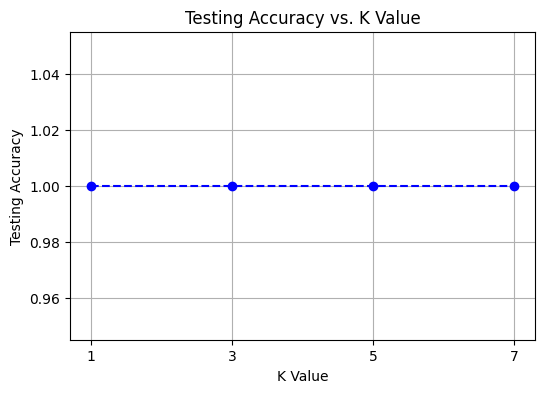

In [7]:
# converting results into a structured dataframe
accuracy_df = pd.DataFrame(results_data)
display_df = accuracy_df[['K Value', 'Training Accuracy', 'Testing Accuracy']]
print("--- Sample Accuracy Table ---")
print(display_df.to_string(index=False))

# plotting testing accuracy versus k value
plt.figure(figsize=(6, 4))
plt.plot(accuracy_df['K Value'], accuracy_df['Raw Test Acc'], marker='o', linestyle='dashed', color='blue')
plt.title("Testing Accuracy vs. K Value")
plt.xlabel("K Value")
plt.ylabel("Testing Accuracy")
plt.xticks(k_values)
plt.grid(True)
plt.show()

**7. Plotting Decision Boundaries**

Visualizing how the KNN algorithm partitions the vector space utilizing the two most separable features (`petal length` and `petal width`).

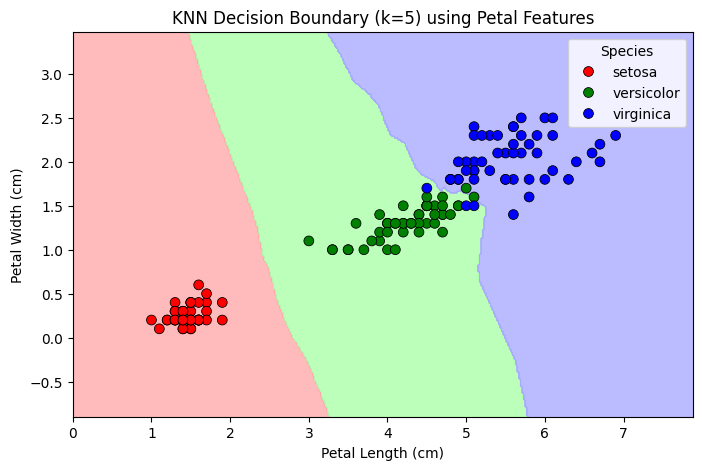

In [8]:
# isolating petal length and petal width for 2d plotting (indices 2 and 3)
X_vis = X[:, 2:4]
y_vis = y

# training a dedicated model for visualization purposes
knn_vis = KNeighborsClassifier(n_neighbors=5)
knn_vis.fit(X_vis, y_vis)

# establishing meshgrid coordinates
x_min, x_max = X_vis[:, 0].min() - 1, X_vis[:, 0].max() + 1
y_min, y_max = X_vis[:, 1].min() - 1, X_vis[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))

# predicting regions
Z = knn_vis.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# plotting the decision boundaries
plt.figure(figsize=(8, 5))
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])

plt.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.8)
sns.scatterplot(x=X_vis[:, 0], y=X_vis[:, 1], hue=iris.target_names[y_vis],
                palette=['red', 'green', 'blue'], edgecolor="black", s=50)

plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.title("KNN Decision Boundary (k=5) using Petal Features")
plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.legend(title="Species")
plt.show()

**8. Extension: The Impact of Feature Scaling**

Demonstrating the necessary data standardization step for distance-based algorithms.

In [9]:
from sklearn.preprocessing import StandardScaler

# initializing the scaler to compute z-scores
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# training a normalized knn model
knn_scaled = KNeighborsClassifier(n_neighbors=5)
knn_scaled.fit(X_train_scaled, y_train)
scaled_test_acc = knn_scaled.score(X_test_scaled, y_test)

print(f"Testing Accuracy without scaling (k=5): {accuracy_df.iloc[2]['Raw Test Acc']:.4f}")
print(f"Testing Accuracy with scaling (k=5): {scaled_test_acc:.4f}")

Testing Accuracy without scaling (k=5): 1.0000
Testing Accuracy with scaling (k=5): 1.0000


**9. Observations & Conclusion**

* **Feature Separability:** Inspection of the pairplots reveals that `Petal Length` and `Petal Width` provide the best separation between the Iris species, whereas sepal dimensions display high overlap.
* **Algorithmic Mechanics:** KNN acts as a supervised, lazy learner. It calculates the Euclidean distance between data points in the vector space and classifies a new sample based on the majority class among its nearest neighbors.
* **Interpreting Probabilities:** The `predict_proba()` function successfully yields the exact probability of a sample belonging to each class. In this execution, the model showed absolute certainty for the first three test samples, outputting probabilities of `[0. 1. 0.]`, `[1. 0. 0.]`, and `[0. 0. 1.]`, which perfectly mapped to the discrete predictions of Versicolor, Setosa, and Virginica.
* **Bias vs. Variance (Analyzing the Accuracies):**
  * Due to the clear separability of the chosen random split, the testing accuracy reached a perfect **$100.00\\%$** across all tested $K$ values. However, the *training* accuracy perfectly demonstrates the bias-variance tradeoff.
  * **Overfitting ($K=1$):** At $K=1$, the model strictly memorized the training data, yielding **$100.00\\%$** training accuracy. This represents a state of low bias but high variance, as the model boundary is severely jagged and fitted to isolated training points.
  * **Optimal Generalization (Larger $K$):** As $k$ increased to 3, 5, and 7, the training accuracy naturally dropped to **$94.29\\%$** and **$95.24\\%$**. This indicates that the regional decision boundaries became smoother. While variance is reduced, the slight drop in training accuracy shows an increase in bias, preventing the model from fitting to noise and ensuring reliable generalization.
* **Significance of Scaling:** Although the Iris dataset possesses uniformly small numerical ranges, feature scaling (standardization) is critically important in distance-based algorithms like KNN. Unscaled features with massive numeric magnitudes can unjustly dominate the Euclidean distance calculation, overpowering smaller-scale yet highly predictive features.